In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv(
    'features_dataset.csv'
)

df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud
0,244486.46,8946.00,0.00,526950.37,771436.84,1,999.0,0
1,3170.28,58089.00,54918.72,0.00,0.00,1,999.0,0
2,8424.74,783.00,0.00,0.00,0.00,1,999.0,0
3,261877.19,7596.00,269473.19,1126627.70,864750.51,1,999.0,0
4,20528.65,2302074.12,2322602.77,82696.17,62167.52,1,999.0,0


In [3]:
#Check Dataset
df.shape

(6362620, 8)

In [4]:
df.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'transaction_frequency', 'velocity', 'isFraud'],
      dtype='object')

In [10]:
#Separate Features
X = df.drop(
    'isFraud',
    axis=1
)

y = df['isFraud']

In [11]:
#Create Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.0013,
    random_state=42
)

In [12]:
#Train Model
iso.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.0013
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [13]:
#Generate Predictions
predictions = iso.predict(X)

In [14]:
#Convert Predictions
predictions = np.where(
    predictions == -1,
    1,
    0
)

In [15]:
#Verify:
pd.Series(predictions).value_counts()

0    6354369
1       8251
Name: count, dtype: int64

In [16]:
#Evaluate Against Actual Fraud
#Precision
precision_score(
    y,
    predictions
)

0.0071506484062537875

In [17]:
#Recall
recall_score(
    y,
    predictions
)

0.0071837331060513815

In [18]:
#F1
f1_score(
    y,
    predictions
)

0.0071671525753158405

In [19]:
#Confusion Matrix
cm = confusion_matrix(
    y,
    predictions
)

cm

array([[6346215,    8192],
       [   8154,      59]])

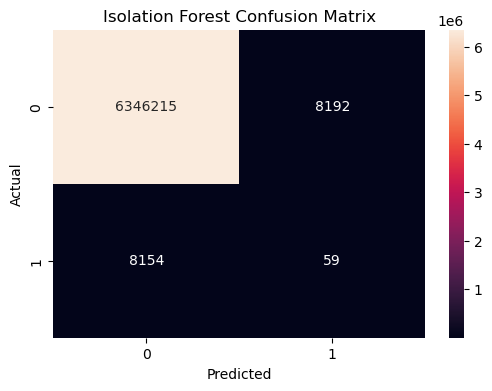

In [20]:
#Visualize:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Isolation Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [21]:
#Calculate FCR
#Fraud Capture Rate
tn, fp, fn, tp = cm.ravel()

In [22]:
fcr = tp / (tp + fn)

print(
    "Fraud Capture Rate:",
    round(fcr,4)
)

Fraud Capture Rate: 0.0072


In [23]:
#Calculate FPR
#False Positive Ratio
fpr = fp / (fp + tn)

print(
    "False Positive Ratio:",
    round(fpr,4)
)

False Positive Ratio: 0.0013


In [24]:
#Generate Anomaly Scores
scores = iso.decision_function(X)

In [25]:
#Add to dataframe:
df['anomaly_score'] = scores

In [26]:
#View Most Suspicious Transactions
df.sort_values(
    by='anomaly_score'
).head(20)

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud,anomaly_score
4337015,30305608.13,0.00,0.00,3.293943e+07,6.341088e+07,2,67.0,0,-0.070323
4757443,38560.15,28210765.39,28249325.54,8.845672e+07,8.841816e+07,1,999.0,0,-0.069202
1698548,1379094.53,22268807.63,23647902.16,6.990648e+07,6.852738e+07,1,999.0,0,-0.069202
3088660,6392504.36,0.00,0.00,5.053623e+07,5.692874e+07,2,25.0,0,-0.068082
4373029,434940.33,24527239.23,24962179.57,5.747612e+07,5.704118e+07,1,999.0,0,-0.066964
3326379,261708.74,24584414.64,24846123.38,2.362512e+08,2.359895e+08,1,999.0,0,-0.066964
2563069,13166481.83,0.00,0.00,3.456599e+07,4.773247e+07,2,284.0,0,-0.066406
4147618,96575.19,30160035.06,30256610.25,6.674909e+07,6.665251e+07,1,999.0,0,-0.066406
3339317,9757.68,27757042.28,27766799.96,3.574125e+07,3.573149e+07,1,999.0,0,-0.066406
3951560,6386.68,25363494.69,25369881.37,4.464659e+07,4.491860e+07,1,999.0,0,-0.065847


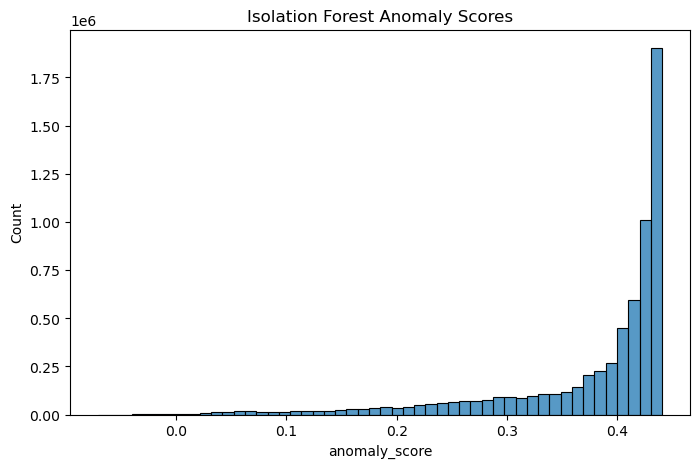

In [27]:
#Visualize Anomaly Scores
plt.figure(figsize=(8,5))

sns.histplot(
    df['anomaly_score'],
    bins=50
)

plt.title(
    'Isolation Forest Anomaly Scores'
)

plt.show()

In [28]:
#Compare Models
comparison = pd.DataFrame({

    'Model': [
        'Random Forest',
        'Isolation Forest'
    ],

    'F1 Score': [
        RF_F1,
        ISO_F1
    ],

    'Recall': [
        RF_RECALL,
        ISO_RECALL
    ],

    'FPR': [
        RF_FPR,
        ISO_FPR
    ]
})

comparison

NameError: name 'RF_F1' is not defined

In [30]:
%whos

Variable               Type               Data/Info
---------------------------------------------------
IsolationForest        ABCMeta            <class 'sklearn.ensemble.<...>iforest.IsolationForest'>
X                      DataFrame          Shape: (6362620, 7)
cm                     ndarray            2x2: 4 elems, type `int64`, 32 bytes
confusion_matrix       function           <function confusion_matrix at 0x0000021A5F84D1C0>
dataframe_columns      function           <function dataframe_colum<...>ns at 0x0000021A0382B1A0>
dataframe_hash         function           <function dataframe_hash at 0x0000021A1549C860>
df                     DataFrame          Shape: (6362620, 9)
dtypes_str             function           <function dtypes_str at 0x0000021A00030C20>
f1_score               function           <function f1_score at 0x0000021A5F84D940>
fcr                    float64            0.0071837331060513815
fn                     int64              8154
fp                     int64      

In [31]:
import pandas as pd

df = pd.read_csv('features_dataset.csv')

In [32]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = rf.predict(X_test)

In [36]:
from sklearn.metrics import (
    f1_score,
    recall_score,
    confusion_matrix
)

RF_F1 = f1_score(y_test, y_pred)

RF_RECALL = recall_score(y_test, y_pred)

cm_rf = confusion_matrix(y_test, y_pred)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

RF_FPR = fp_rf / (fp_rf + tn_rf)

print("RF_F1 =", RF_F1)
print("RF_RECALL =", RF_RECALL)
print("RF_FPR =", RF_FPR)

RF_F1 = 0.8179310344827586
RF_RECALL = 0.7218502738892271
RF_FPR = 5.5866756997704745e-05


In [37]:
ISO_F1 = f1_score(y, predictions)

ISO_RECALL = recall_score(y, predictions)

cm_iso = confusion_matrix(y, predictions)

tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()

ISO_FPR = fp_iso / (fp_iso + tn_iso)

print("ISO_F1 =", ISO_F1)

ISO_F1 = 0.0071671525753158405


In [38]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Isolation Forest'],
    'F1 Score': [RF_F1, ISO_F1],
    'Recall': [RF_RECALL, ISO_RECALL],
    'FPR': [RF_FPR, ISO_FPR]
})

comparison

,Model,F1 Score,Recall,FPR
0,Random Forest,0.817931,0.721850,0.000056
1,Isolation Forest,0.007167,0.007184,0.001289


In [39]:
print(type(y_test))

<class 'pandas.core.series.Series'>


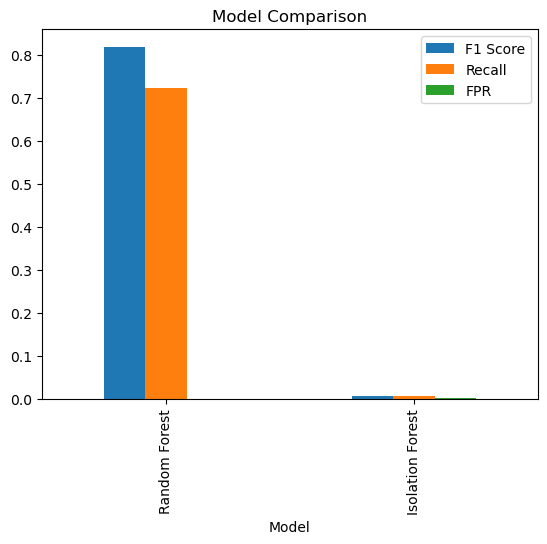

In [40]:
#Visualize Comparison
comparison.set_index(
    'Model'
).plot(
    kind='bar'
)

plt.title(
    'Model Comparison'
)

plt.show()

In [41]:
#Save Isolation Forest Model
import joblib

joblib.dump(
    iso,
    'isolation_forest_model.pkl'
)

['isolation_forest_model.pkl']

In [42]:
#Verify:
import os

os.path.exists(
    'isolation_forest_model.pkl'
)

True

In [43]:
#Create AI Fraud Flag
df['ai_fraud_flag'] = predictions

In [44]:
#View
df[
    [
        'amount',
        'velocity',
        'anomaly_score',
        'ai_fraud_flag'
    ]
].head()

KeyError: "['anomaly_score'] not in index"

In [45]:
print(df.columns.tolist())

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'transaction_frequency', 'velocity', 'isFraud', 'ai_fraud_flag']


In [46]:
'anomaly_score' in df.columns

False

In [47]:
scores = iso.decision_function(X)

df['anomaly_score'] = scores

In [48]:
'ai_fraud_flag' in df.columns

True

In [49]:
print(df.columns.tolist())

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'transaction_frequency', 'velocity', 'isFraud', 'ai_fraud_flag', 'anomaly_score']


In [50]:
df[
    [
        'amount',
        'velocity',
        'anomaly_score',
        'ai_fraud_flag'
    ]
].head()

,amount,velocity,anomaly_score,ai_fraud_flag
0,244486.46,999.0,0.411647,0
1,3170.28,999.0,0.433367,0
2,8424.74,999.0,0.439038,0
3,261877.19,999.0,0.385170,0
4,20528.65,999.0,0.302614,0


In [51]:
print(df.columns.tolist())

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'transaction_frequency', 'velocity', 'isFraud', 'ai_fraud_flag', 'anomaly_score']


In [52]:
#Export Results
df.to_csv(
    'fraud_predictions.csv',
    index=False
)